In [ ]:
include("/home/fhechenberger/jupyter/julia/sivers/sivers.jl")
using .Sivers

# Parameters handled separately
include("/home/fhechenberger/jupyter/julia/sivers/parameters.jl")
using .parameters: params
# # Parameters and SU(Nc) algebra set in parameters.jl
alpha_s = params.alpha_s
Nc = params.Nc
mN = params.mN
mq = params.mq
dabc2 = (Nc^2 - 4) * (Nc^2 - 1) / Nc ;

In [5]:
using Cuba
function odderon_distribution_2(s01::Integer,s02::Integer,
                                k::Vector{<:Real},Δ::Vector{<:Real},
                                mu=0.01)
    if !iszero(Δ)
        throw(ArgumentError("Implementation currently only for vanishing Δ."))
    end
    function generate_x123(x)
        # 2d input for d3x = dx1 dx2 dx3 integral
        # Cuba samples are [0,1]^n
        x1 = x[1]
        x2 = (1 - x1) * x[2]
        x3 = 1 - x1 - x2
        dx1dx2 = (1-x1)
        return x1, x2, x3, dx1dx2
    end

    function generate_k123(x)
        # 4d input for d4k = d2k1 d2k2 integral
        # Cuba samples are [0,1]^n so we
        # Transform to polar coordinates
        r1 = x[1] / (1 - x[1])  # r ∈ [0, ∞)
        ϕ1 = 2π * x[2]          # φ ∈ [0, 2π)
        # Same for k2
        r2 = x[3] / (1 - x[3])
        ϕ2 = 2π * x[4]
    
        # Reconstruct momenta in polar coordinates
        k1 = [r1 * cos(ϕ1), r1 * sin(ϕ1)]
        k2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]
        k3 = - (k1 + k2)  # Enforce transverse momentum conservation

        # Jacobian
        dk1 = r1 / (1 - x[1])^2 # r1
        dk2 = r2 / (1 - x[3])^2 # r2
        d2ϕ = (2π)^2 # dϕ1 * dϕ2
        d2k = dk1 * dk2
        d4k = d2ϕ * d2k
        return k1, k2, k3, d4k
    end

    function generate_q2(x)
        # 2d input for dq2 integral
        # Cuba samples are [0,1]^n so we
        # Transform to polar coordinates
        r2 = x[1] / (1 - x[1]) # r ∈ [0, ∞)
        ϕ2 = 2π * x[2]          # φ ∈ [0, 2π)
        
        # Reconstruct momentum in polar coordinates
        q2 = [r2 * cos(ϕ2), r2 * sin(ϕ2)]

        # Jacobian
        dq2 = r2 / (1 - x[1])^2
        dϕ = (2π)
        d2q2 = dq2 * dϕ
        return q2, d2q2
    end
    
    function one_body_kin(i,j123,q1,q2,q3)
        # Momentum inflow [q1 + q2 + q3] at j123
        # i is k_prime (quark) index, j123 quark line with 
        # momentum inflow q1 + q2 + q3 from gluon.
        delta_kiprime =  kronecker_delta(i, j123) * (q1 + q2 + q3)
        return delta_kiprime
    end
    function two_body_kin(i,j12,j3,l,q1,q2,q3)
        # Momentum inflow [q1 + q2,j12] [q3,j3] at j12 and j3
        # i is k_prime (quark) index, j12, j3 quark line with
        # momentum inflow q1 + q2 and q3 from gluon.
        # Addtional terms from permutations, so in total 3 contributions
        # which we distinguish by l
        if l == 1 # [q2 + q3,j12] [q1,j3]
            delta_kiprime =  kronecker_delta(i, j12) * (q2 + q3) + kronecker_delta(i, j3) * q1
        elseif l == 2 # [q1 + q3,j12] [q2,j3]
            delta_kiprime =  kronecker_delta(i, j12) * (q1 + q3) + kronecker_delta(i, j3) * q2
        elseif l == 3 # [q1 + q2,j12] [q3,j3]
            delta_kiprime =  kronecker_delta(i, j12) * (q1 + q2) + kronecker_delta(i, j3) * q3
        end
        return delta_kiprime
    end
    function three_body_kin(i,j1,j2,j3,q1,q2,q3)
        # Momentum inflow [q1,j1] [q2,j2] [q3,j3]
        # i is k_prime (quark) index, j1, j2, j3 are gluons with momenta
        # q1, q2 and q3, respectively, attached to quark lines.
        delta_kiprime = kronecker_delta(i, j1) * q1 + kronecker_delta(i, j2) * q2 + kronecker_delta(i, j3) * q3
        return delta_kiprime
    end
    function compute_ccc(x1,x2,x3,q1,q2,q3,k1,k2,k3)
        # Cubic color corellator without Jacobian
        # Precompute incoming baryon wavefunction
        wf1 = compute_wavefunction(s01,k1, k2, k3, x1, x2, x3)
        # Initialize outgoing wavefunction array
        total_wf2 = Array{ComplexF64}(undef, 2, 2, 2)
        fill!(total_wf2, ComplexF64(0.0, 0.0))

        # Constant parts
        k1prime0, k2prime0, k3prime0 = k1 - Δ, k2 - Δ, k3 - Δ
        # Sum over one-body, two-body and three-body kinematics
        # One-body
        for j123 in 1:3
            k1prime = k1prime0 - one_body_kin(1,j123,q1,q2,q3)
            k2prime = k2prime0 - one_body_kin(2,j123,q1,q2,q3)
            k3prime = k3prime0 - one_body_kin(3,j123,q1,q2,q3)
            wf2 = compute_wavefunction(s02,k1prime,k2prime,k3prime,x1,x2,x3)
            # Sum outgoing wavefunctions
            total_wf2 .+= wf2
        end
        # Two-body
        # Addtional terms from permutations, so we have an extra sum over k
        for l in 1:3, j12 in 1:3, j3 in 1:3
            if j12 == j3
                continue
            end
            k1prime = k1prime0 - two_body_kin(1,j12,j3,l,q1,q2,q3)
            k2prime = k2prime0 - two_body_kin(2,j12,j3,l,q1,q2,q3)
            k3prime = k3prime0 - two_body_kin(3,j12,j3,l,q1,q2,q3)
            wf2 = compute_wavefunction(s02,k1prime,k2prime,k3prime,x1,x2,x3)
            # Sum outgoing wavefunctions
            total_wf2 .-= .5 * wf2 
        end
        # Three-body
        for j1 in 1:3, j2 in 1:3, j3 in 1:3
            if j1 == j2 || j1 == j3 || j2 == j3
                continue
            end
            k1prime = k1prime0 - three_body_kin(1,j1,j2,j3,q1,q2,q3)
            k2prime = k2prime0 - three_body_kin(2,j1,j2,j3,q1,q2,q3)
            k3prime = k3prime0 - three_body_kin(3,j1,j2,j3,q1,q2,q3)
            wf2 = compute_wavefunction(s02,k1prime,k2prime,k3prime,x1,x2,x3)
            # Sum outgoing wavefunctions
            total_wf2 .+= wf2
        end
        # Perform spin sum once
        total = spin_sum(wf1,total_wf2)
        ccc = total
        # Multiply with prefactors from integration
        ccc *= 1 / (4π)^2 / (2π)^2
        return ccc
    end
    function integrand(x,f)
        # Transform [0,1]^8 cuba samples to physical variables
        x1, x2, x3, dx1dx2 = generate_x123(x[1:2])  # 2d
        k1, k2, k3, d4k = generate_k123(x[3:6]) # 4d
        q2, d2q2 = generate_q2(x[7:8])          # 2d
        # Jacobian
        d8x = dx1dx2 * d4k * d2q2 # 2 + 4 + 2 = 8d integral

        total = 0
        for s in (+1,-1)
            # Flip momenta to project out Sivers function
            q1, q2, q3 = s * k, s * q2, - s * (k + q2)
            k1, k2, k3 = s * k1, s * k2, s * k3  
            ccc = compute_ccc(x1,x2,x3,q1,q2,q3,k1,k2,k3)
            total += s * ccc
        end
        # Regenerate initial q2
        q2, _ = generate_q2(x[7:8])
        q3 = k + q2
        q22 = sum(q2.^2)
        q32 = sum(q3.^2)
        # Add regulator
        mu2 = mu^2
        q22 += mu2
        q32 += mu2
        # Same denominator
        # for both terms once momenta
        # have been flipped
        den = q22 * q32  
        total *=  d8x / den

        f[1] = real(total)
        f[2] = imag(total)
    end
    integral, err = cuhre(integrand, 8, 2, atol=1e-14, rtol=1e-12);
    # Prefactors 
    # prf = - 2π^3 * alpha_s^3 * dabc2 / Nc
    # For now, factor of g^6 = 1, for simplicity
    prf = - dabc2 / Nc / 32
    # We return the result up to a factor of k^2
    result = prf * complex(integral[1],integral[2])
    return result
end

# Check it vanishes for no spin-flip
no_flip = odderon_distribution_2(1,1,[.1,0],[0,0])
println(no_flip)
# Non-vanishing for spin-flip
flip = odderon_distribution_2(1,-1,[.1,0],[0,0])
println(flip)

-0.0 - 0.0im
-37.78009044895118 - 1.7411640589932221e-15im


In [ ]:
############################################################################
############################################################################
###   ___  _     _       _          __  __   _          _                ###
###  / _ \| | __| |  ___| |_ _   _ / _|/ _| | |__   ___| | _____      __ ###
### | | | | |/ _` | / __| __| | | | |_| |_  | '_ \ / _ \ |/ _ \ \ /\ / / ###
### | |_| | | (_| | \__ \ |_| |_| |  _|  _| | |_) |  __/ | (_) \ V  V /  ###
###  \___/|_|\__,_| |___/\__|\__,_|_| |_|   |_.__/ \___|_|\___/ \_/\_/   ###
###                                                                      ###
############################################################################
############################################################################

In [ ]:
Δ_array = 0:.125:3.3
n = length(Δ_array)
# Initialize array
results = Vector{ComplexF64}(undef, n)
for i in 1:n
    Δ = Δ_array[i]
    results[i] = f1_form_factor([Δ, 0.0])
end

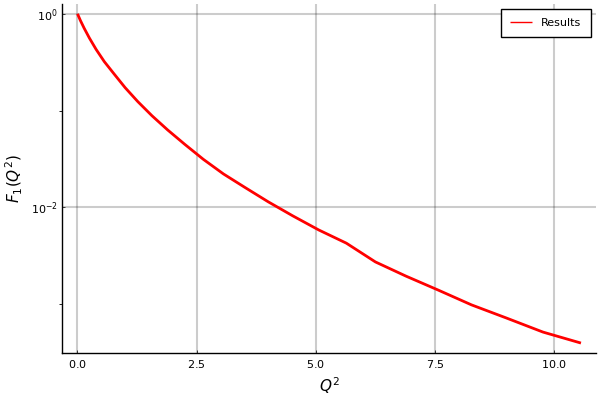

In [52]:
using Plots, LaTeXStrings
pyplot()
Q2 = Δ_array.^2

plot(Q2, real(results),
    label="Results",              # Label for the data series
    xlabel=L"Q^2",             # Label for the x-axis
    ylabel=L"F_1(Q^2)",       # Label for the y-axis
    markersize=5,                 # Optional: Set marker size
    markercolor=:blue,            # Optional: Set marker color
    linewidth=2,                  # Optional: Set line width
    linecolor=:red,                # Optional: Set line color (if not using :scatter, or to connect points)
    yscale=:log10,
    gridalpha=0.2,        # Increase opacity (0.0=invisible, 1.0=solid)
    gridlinewidth=1.5,    # Increase line thickness (default is often < 1)
)

Things I have tried to speed up:
- Summation outside integrand and summing contributions obtained by cuhre slightly faster
- Summation inside integrand is slightly slower
- Parallelizing with CUBACORES actually takes longer
- No speed up with parallelization in general